# Migrant Education Analysis — Canada

## 1. Import Required Libraries

In [1]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

## 2. Load and Inspect the Data

In [2]:
import glob

df_raw = pd.concat(
    [pd.read_csv(f, encoding="utf-8-sig") for f in sorted(glob.glob("../data/*.csv"))],
    ignore_index=True
)
df_raw.head()

,REF_DATE,GEO,DGUID,Percent,Gender (3a),Age (15A),First official language spoken (5),Immigrant and generation status (9),Visible minority (15),"Highest certificate, diploma or degree (7A)",...,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021,Canada,2021A000011124,Percent,Total - Gender,Total - Age,Total - First official language spoken,Total – Immigrant and generation status,Total - Visible minority,"Total - Highest certificate, diploma or degree",...,0,units,0,NaN,1.1.1.1.1.1.1.1.4,100.0,NaN,NaN,NaN,1
1,2021,Canada,2021A000011124,Percent,Total - Gender,Total - Age,Total - First official language spoken,Total – Immigrant and generation status,Total - Visible minority,"No certificate, diploma or degree",...,0,units,0,NaN,1.1.1.1.1.1.1.2.4,23.7,NaN,NaN,NaN,1
2,2021,Canada,2021A000011124,Percent,Total - Gender,Total - Age,Total - First official language spoken,Total – Immigrant and generation status,Total - Visible minority,High (secondary) school diploma or equivalency...,...,0,units,0,NaN,1.1.1.1.1.1.1.3.4,25.6,NaN,NaN,NaN,1
3,2021,Canada,2021A000011124,Percent,Total - Gender,Total - Age,Total - First official language spoken,Total – Immigrant and generation status,Total - Visible minority,Postsecondary certificate or diploma below bac...,...,0,units,0,NaN,1.1.1.1.1.1.1.4.4,32.6,NaN,NaN,NaN,1
4,2021,Canada,2021A000011124,Percent,Total - Gender,Total - Age,Total - First official language spoken,Total – Immigrant and generation status,Total - Visible minority,Bachelor’s degree or higher,...,0,units,0,NaN,1.1.1.1.1.1.1.5.4,18.2,NaN,NaN,NaN,1


In [3]:
df_raw.info()
print("\nBasic statistics:")
df_raw.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 22 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   REF_DATE                                     420 non-null    int64  
 1   GEO                                          420 non-null    str    
 2   DGUID                                        420 non-null    str    
 3   Percent                                      420 non-null    str    
 4   Gender (3a)                                  420 non-null    str    
 5   Age (15A)                                    420 non-null    str    
 6   First official language spoken (5)           420 non-null    str    
 7   Immigrant and generation status (9)          420 non-null    str    
 8   Visible minority (15)                        420 non-null    str    
 9   Highest certificate, diploma or degree (7A)  420 non-null    str    
 10  Census year (

,REF_DATE,GEO,DGUID,Percent,Gender (3a),Age (15A),First official language spoken (5),Immigrant and generation status (9),Visible minority (15),"Highest certificate, diploma or degree (7A)",...,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
count,420.0,420,420,420,420,420,420,420,420,420,...,420.0,420,420.0,0.0,420,420.000000,0.0,0.0,0.0,420.0
unique,NaN,1,1,1,1,1,1,1,15,7,...,NaN,1,NaN,NaN,420,NaN,NaN,NaN,NaN,NaN
top,NaN,Canada,2021A000011124,Percent,Total - Gender,Total - Age,Total - First official language spoken,Total – Immigrant and generation status,Total - Visible minority,"Total - Highest certificate, diploma or degree",...,NaN,units,NaN,NaN,1.1.1.1.1.1.1.1.4,NaN,NaN,NaN,NaN,NaN
freq,NaN,420,420,420,420,420,420,420,28,60,...,NaN,420,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
mean,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,NaN,32.912619,NaN,NaN,NaN,1.0
std,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,NaN,28.616147,NaN,NaN,NaN,0.0
min,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,NaN,4.400000,NaN,NaN,NaN,1.0
25%,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,NaN,16.700000,NaN,NaN,NaN,1.0
50%,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,NaN,23.700000,NaN,NaN,NaN,1.0
75%,2021.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,NaN,32.200000,NaN,NaN,NaN,1.0


## 3. Data Cleaning and Preprocessing

In [5]:
# Rename columns for readability
df = df_raw.rename(columns={
    "REF_DATE": "year",
    "GEO": "geography",
    "Visible minority (15)": "visible_minority",
    "Highest certificate, diploma or degree (7A)": "education_level",
    "Immigrant and generation status (9)": "immigrant_status",
    "Gender (3a)": "gender",
    "Age (15A)": "age",
    "First official language spoken (5)": "language",
    "VALUE": "pct",
    "Census year (4)": "census_year",
})

# Convert percentage to numeric
df["pct"] = pd.to_numeric(df["pct"], errors="coerce")

# Check missing values
print("Missing values per column:")
print(df[["year","geography","visible_minority","education_level","pct"]].isnull().sum())

# Debug: Check sample values to understand the data structure
print("\n=== Sample of unique values ===")
print("Gender samples:", df["gender"].unique()[:5])
print("Age samples:", df["age"].unique()[:5])
print("Language samples:", df["language"].unique()[:5])
print("Immigrant_status samples:", df["immigrant_status"].unique()[:5])
print("Geography samples:", df["geography"].unique())

# Keep only the rows relevant for a national-level snapshot
# (Gender = Total, Age = Total, Language = Total, Immigrant Status = Total)
mask = (
    (df["gender"] == "Total - Gender") &
    (df["age"] == "Total - Age") &
    (df["language"] == "Total - First official language spoken") &
    (df["immigrant_status"] == "Total – Immigrant and generation status") &
    (df["geography"] == "Canada")
)
df_clean = df[mask].copy()
print(f"\nRows after filtering to totals: {len(df_clean)}")

# Drop aggregate rows that would cause double-counting in charts
AGGREGATES = ["Total - Visible minority", "Total - Highest certificate, diploma or degree"]
df_analysis = df_clean[
    ~df_clean["visible_minority"].isin(AGGREGATES) &
    ~df_clean["education_level"].str.startswith("Total", na=False)
].copy()

print(f"Rows for analysis (no aggregates): {len(df_analysis)}")
df_analysis[["visible_minority","education_level","pct"]].head(10)

Missing values per column:
year                0
geography           0
visible_minority    0
education_level     0
pct                 0
dtype: int64

=== Sample of unique values ===
Gender samples: <StringArray>
['Total - Gender']
Length: 1, dtype: str
Age samples: <StringArray>
['Total - Age']
Length: 1, dtype: str
Language samples: <StringArray>
['Total - First official language spoken']
Length: 1, dtype: str
Immigrant_status samples: <StringArray>
['Total – Immigrant and generation status']
Length: 1, dtype: str
Geography samples: <StringArray>
['Canada']
Length: 1, dtype: str

Rows after filtering to totals: 420
Rows for analysis (no aggregates): 336


,visible_minority,education_level,pct
8,Total visible minority population,"No certificate, diploma or degree",20.2
9,Total visible minority population,High (secondary) school diploma or equivalency...,24.9
10,Total visible minority population,Postsecondary certificate or diploma below bac...,27.0
11,Total visible minority population,Bachelor’s degree or higher,28.0
12,Total visible minority population,Bachelor's degree,17.8
13,Total visible minority population,"University certificate, diploma or degree abov...",10.1
15,South Asian,"No certificate, diploma or degree",20.6
16,South Asian,High (secondary) school diploma or equivalency...,26.0
17,South Asian,Postsecondary certificate or diploma below bac...,23.7
18,South Asian,Bachelor’s degree or higher,29.7


In [6]:
# Build a pivoted wide-format table for quick lookups and comparisons
# Rows = visible minority groups, Columns = education levels
edu_order = [
    "No certificate, diploma or degree",
    "High (secondary) school diploma or equivalency certificate",
    "Postsecondary certificate or diploma below bachelor level",
    "Bachelor's degree",
    "University certificate, diploma or degree above bachelor level",
    "Bachelor's degree or higher",
]

# Shorter labels for charts
edu_short = {
    "No certificate, diploma or degree": "No credential",
    "High (secondary) school diploma or equivalency certificate": "High school",
    "Postsecondary certificate or diploma below bachelor level": "Post-sec (below Bach.)",
    "Bachelor's degree": "Bachelor's",
    "University certificate, diploma or degree above bachelor level": "Above bachelor",
    "Bachelor's degree or higher": "Bach. or higher",
}

df_analysis["edu_short"] = df_analysis["education_level"].map(edu_short)

pivot = (
    df_analysis
    .groupby(["visible_minority", "education_level"])["pct"]
    .first()
    .unstack("education_level")
    .reindex(columns=[c for c in edu_order if c in df_analysis["education_level"].unique()])
)

print("Pivoted table shape:", pivot.shape)
pivot.round(1)

Pivoted table shape: (14, 5)


education_level,"No certificate, diploma or degree",High (secondary) school diploma or equivalency certificate,Postsecondary certificate or diploma below bachelor level,Bachelor's degree,"University certificate, diploma or degree above bachelor level"
visible_minority,,,,,
Arab,17.6,21.6,25.7,21.1,14.0
Black,21.5,25.5,37.5,9.7,5.8
Chinese,21.1,24.1,21.7,21.9,11.2
Filipino,10.9,21.1,34.6,26.6,6.8
Japanese,11.4,25.1,31.7,22.3,9.5
Korean,12.1,24.9,21.6,28.1,13.2
Latin American,22.2,26.4,32.2,11.2,8.1
Multiple visible minorities,20.6,24.3,29.6,17.0,8.4
Not a visible minority,24.3,25.7,33.6,10.5,5.9


## 4. Education Distribution Across Visible Minority Groups

The grouped bar chart shows the full percentage breakdown for each education level across every visible minority group.

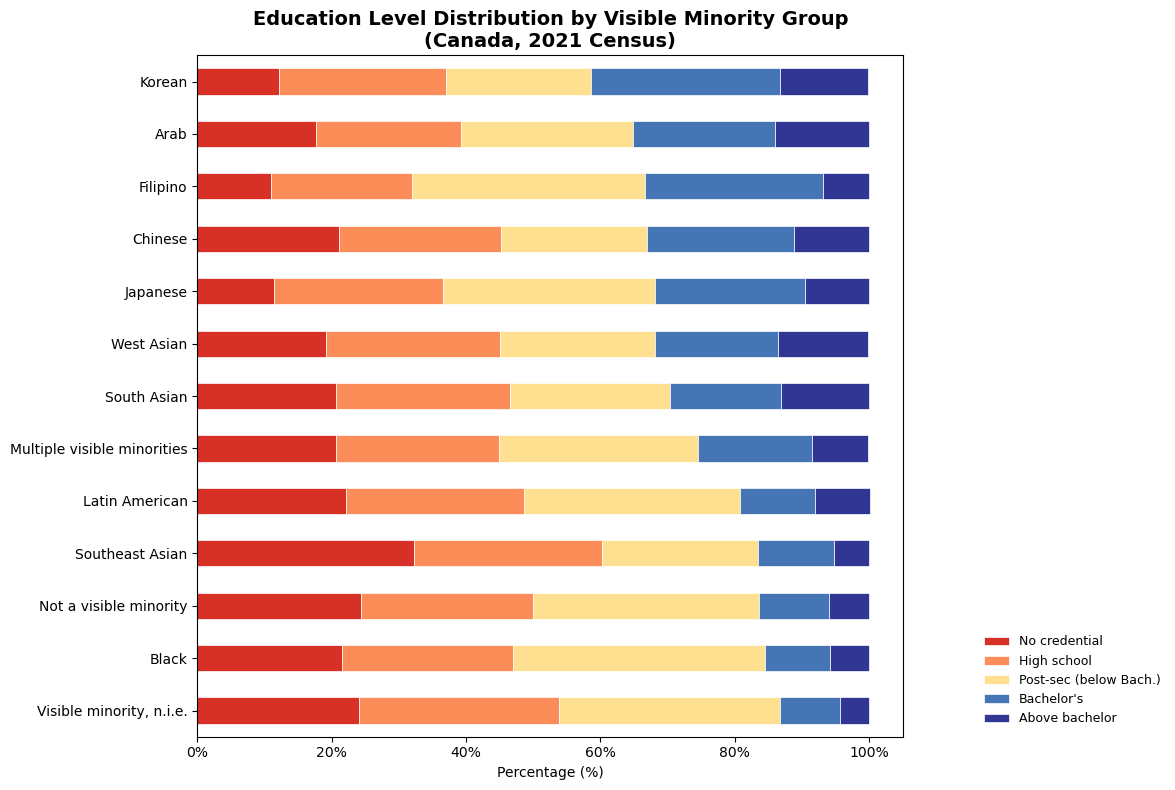

In [8]:
# Education levels to include in the stacked chart
edu_stack = [
    "No certificate, diploma or degree",
    "High (secondary) school diploma or equivalency certificate",
    "Postsecondary certificate or diploma below bachelor level",
    "Bachelor's degree",
    "University certificate, diploma or degree above bachelor level",
]

pivot_stack = (
    df_analysis[df_analysis["education_level"].isin(edu_stack) &
                ~df_analysis["visible_minority"].isin(["Total - Visible minority", "Total visible minority population"])]
    .groupby(["visible_minority", "education_level"])["pct"]
    .first()
    .unstack("education_level")
    .reindex(columns=edu_stack)
)

# Sort by bachelor's + above attainment, then apply short labels
pivot_stack = pivot_stack.loc[pivot_stack[edu_stack[-2:]].sum(axis=1).sort_values().index]
pivot_stack.columns = [edu_short[c] for c in edu_stack]

fig, ax = plt.subplots(figsize=(13, 8))
colors = ["#d73027", "#fc8d59", "#fee090", "#4575b4", "#313695"]
pivot_stack.plot(kind="barh", stacked=True, ax=ax, color=colors, edgecolor="white", linewidth=0.5)

ax.set_xlabel("Percentage (%)")
ax.set_title("Education Level Distribution by Visible Minority Group\n(Canada, 2021 Census)", fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.legend(loc="lower right", bbox_to_anchor=(1.38, 0), frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig("fig1_education_distribution.png", bbox_inches="tight")
plt.show()

## 5. Bachelor's Degree or Higher — Ranking and Over/Under-Representation

For each group we compute the **percentage-point gap** relative to the national average (Group % − National %).

A positive gap means the group is *over-represented* at the bachelor's level relative to the national average.

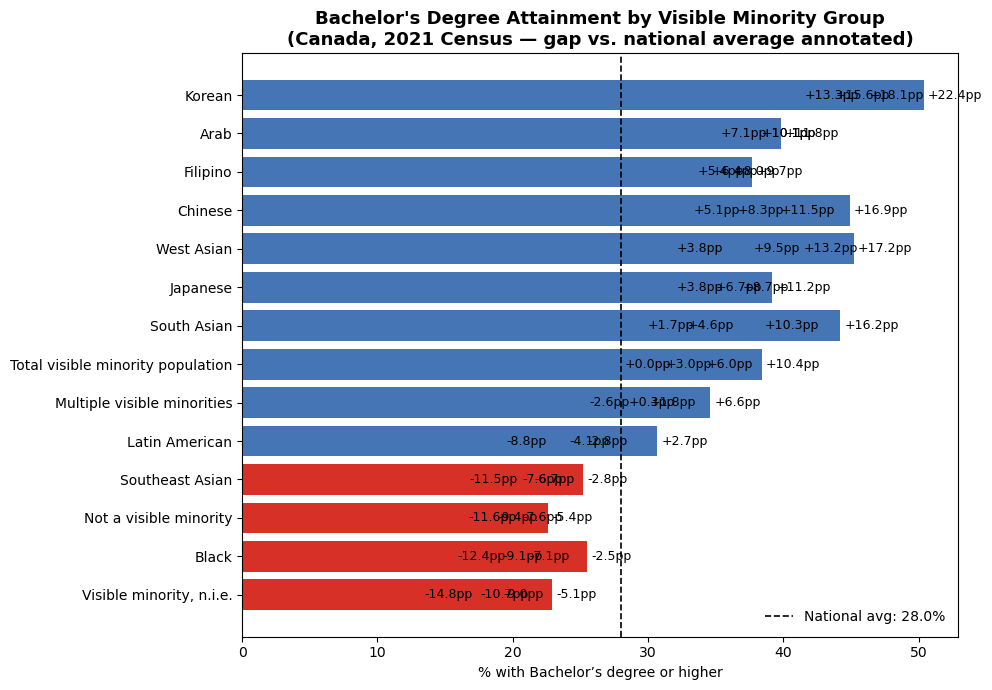

,visible_minority,bach_pct,gap_pp
88,"Visible minority, n.i.e.",13.2,-14.8
32,Black,15.6,-12.4
102,Not a visible minority,16.4,-11.6
60,Southeast Asian,16.5,-11.5
193,"Visible minority, n.i.e.",17.3,-10.7
207,Not a visible minority,18.6,-9.4
137,Black,18.9,-9.1
298,"Visible minority, n.i.e.",19.0,-9.0
53,Latin American,19.2,-8.8
312,Not a visible minority,20.4,-7.6


In [9]:
# Get the correct education level string from the data itself to avoid encoding issues
bach_level = [e for e in df_clean["education_level"].unique() if "bachelor" in e.lower() and "higher" in e.lower()][0]

national_bach = df_clean[
    (df_clean["education_level"] == bach_level) &
    (df_clean["visible_minority"] == "Total visible minority population")
]["pct"].values[0]

df_bach = (
    df_analysis[df_analysis["education_level"] == bach_level]
    .assign(delta=lambda x: x["pct"] - national_bach)
    .sort_values("pct")
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#d73027" if d < 0 else "#4575b4" for d in df_bach["delta"]]
bars = ax.barh(df_bach["visible_minority"], df_bach["pct"], color=colors)

for bar, delta in zip(bars, df_bach["delta"]):
    sign = "+" if delta >= 0 else ""
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{sign}{delta:.1f}pp", va="center", fontsize=9)

ax.axvline(national_bach, color="black", linestyle="--", linewidth=1.2,
           label=f"National avg: {national_bach:.1f}%")
ax.set_xlabel(f"% with {bach_level}")
ax.set_title("Bachelor's Degree Attainment by Visible Minority Group\n(Canada, 2021 Census — gap vs. national average annotated)",
             fontsize=13, fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig2_bachelors_ranking.png", bbox_inches="tight")
plt.show()

df_bach[["visible_minority", "pct", "delta"]].rename(
    columns={"pct": "bach_pct", "delta": "gap_pp"}).round(1)

## 6. No Certificate or Diploma Analysis

Groups that deviate significantly from the national mean are flagged using the z-score:

$$z = \frac{x - \mu}{\sigma}$$

Groups with $|z| > 1.0$ are highlighted.

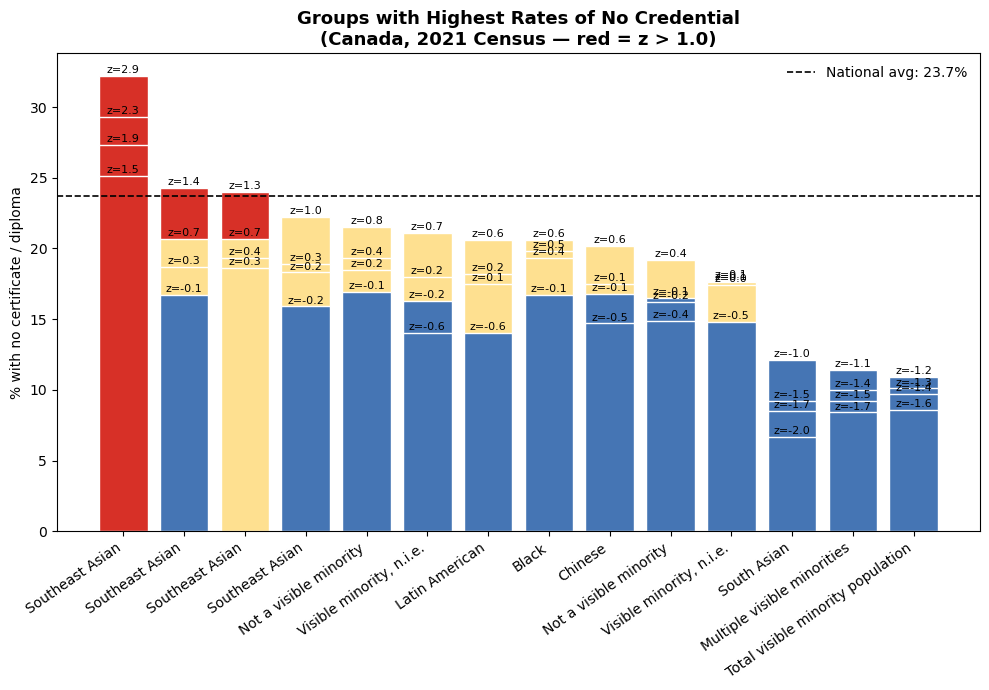

In [10]:
no_cred = "No certificate, diploma or degree"

national_nocred = df_clean[
    (df_clean["education_level"] == no_cred) &
    (df_clean["visible_minority"] == "Total - Visible minority")
]["pct"].values[0]

df_nocred = (
    df_analysis[df_analysis["education_level"] == no_cred]
    .assign(z=lambda x: stats.zscore(x["pct"]))
    .sort_values("pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#d73027" if z > 1.0 else "#fee090" if z > 0 else "#4575b4" for z in df_nocred["z"]]
bars = ax.bar(df_nocred["visible_minority"], df_nocred["pct"], color=colors, edgecolor="white")

for bar, z_val in zip(bars, df_nocred["z"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"z={z_val:.1f}", ha="center", fontsize=8)

ax.axhline(national_nocred, color="black", linestyle="--", linewidth=1.2,
           label=f"National avg: {national_nocred:.1f}%")
ax.set_ylabel("% with no certificate / diploma")
ax.set_title("Groups with Highest Rates of No Credential\n(Canada, 2021 Census — red = z > 1.0)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(df_nocred["visible_minority"], rotation=35, ha="right")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig3_no_credential.png", bbox_inches="tight")
plt.show()

## 7. Comparative Analysis: Visible Minority vs. Non-Visible Minority

Side-by-side comparison of "Total visible minority population" vs "Not a visible minority" across all education levels, with percentage-point differences labelled.

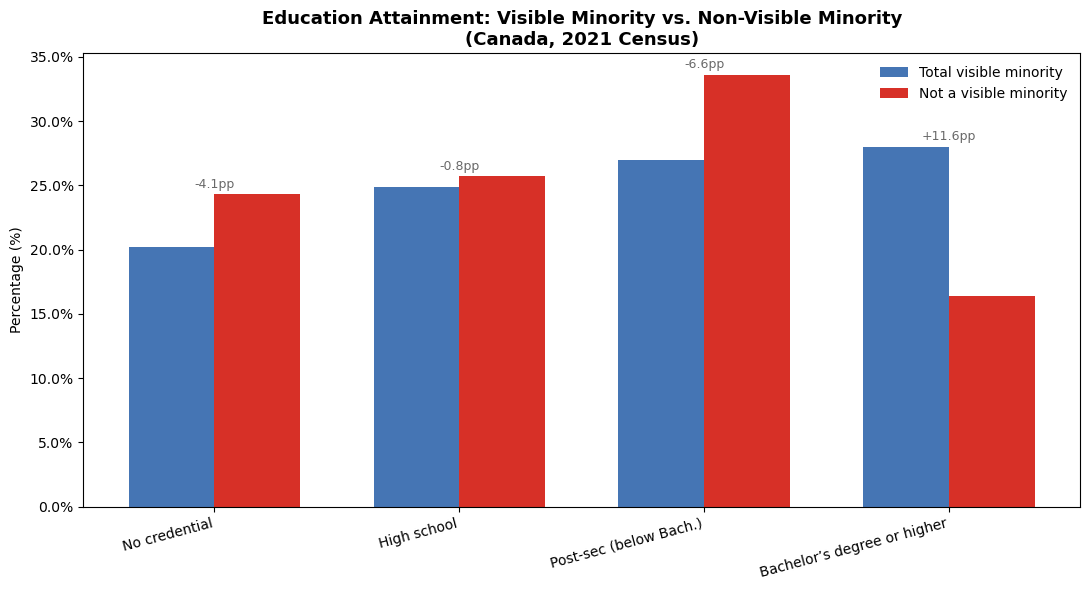

In [11]:
compare_groups = ["Total visible minority population", "Not a visible minority"]

# Get education levels from data to avoid apostrophe encoding issues
all_edu = df_clean["education_level"].unique()
compare_edu = [
    [e for e in all_edu if "no certificate" in e.lower()][0],
    [e for e in all_edu if "secondary" in e.lower() and "school" in e.lower()][0],
    [e for e in all_edu if "postsecondary" in e.lower() and "below" in e.lower()][0],
    [e for e in all_edu if "bachelor" in e.lower() and "higher" in e.lower()][0],
]

# Use groupby().first() to handle duplicates instead of pivot
pivot_comp = (
    df_clean[df_clean["visible_minority"].isin(compare_groups) &
             df_clean["education_level"].isin(compare_edu)]
    .groupby(["education_level", "visible_minority"])["pct"]
    .first()
    .unstack("visible_minority")
)
pivot_comp = pivot_comp.reindex(compare_edu)
pivot_comp.index = [edu_short.get(c, c) for c in pivot_comp.index]
pivot_comp["diff_pp"] = pivot_comp["Total visible minority population"] - pivot_comp["Not a visible minority"]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(pivot_comp))
w = 0.35
ax.bar(x - w/2, pivot_comp["Total visible minority population"], w,
       label="Total visible minority", color="#4575b4")
ax.bar(x + w/2, pivot_comp["Not a visible minority"], w,
       label="Not a visible minority", color="#d73027")

for i, diff in enumerate(pivot_comp["diff_pp"]):
    sign = "+" if diff >= 0 else ""
    ax.annotate(f"{sign}{diff:.1f}pp",
                xy=(x[i], max(pivot_comp["Total visible minority population"].iloc[i],
                               pivot_comp["Not a visible minority"].iloc[i]) + 0.5),
                ha="center", fontsize=9, color="dimgray")

ax.set_xticks(x)
ax.set_xticklabels(pivot_comp.index, rotation=15, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Education Attainment: Visible Minority vs. Non-Visible Minority\n(Canada, 2021 Census)",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("fig4_vm_vs_nonvm.png", bbox_inches="tight")
plt.show()

## 8. Multi-Year Trend Analysis (2006–2021)

Tracks how bachelor's degree attainment has changed across census years for key visible minority groups.

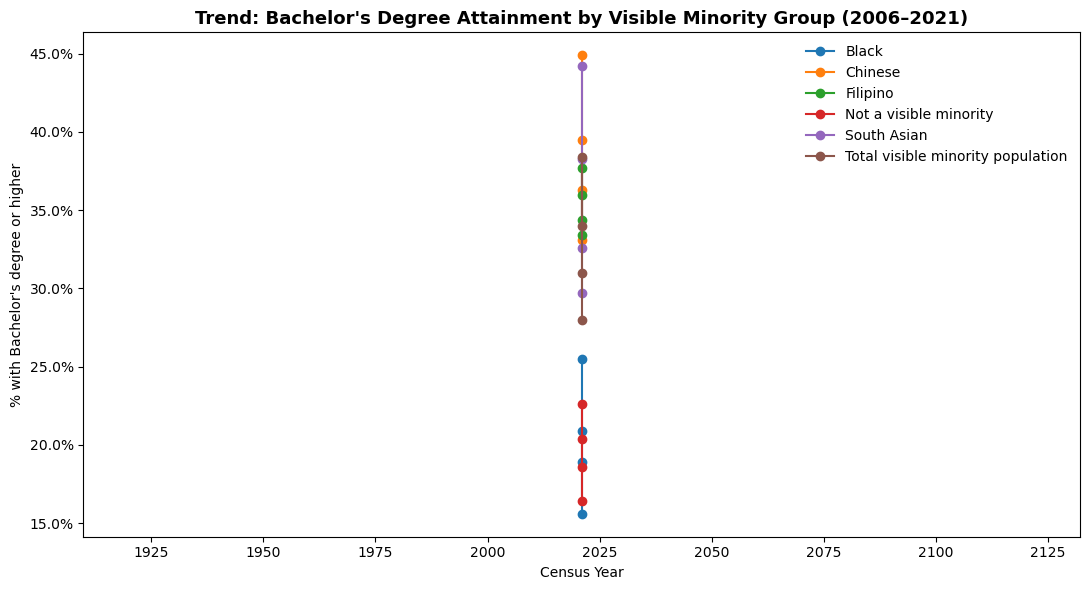

In [14]:
trend_groups = [
    "Total visible minority population",
    "South Asian", "Chinese", "Black",
    "Filipino", "Not a visible minority",
]

# Look up the exact string from data to avoid apostrophe encoding issues
all_edu = df_clean["education_level"].unique()
bach_edu = [e for e in all_edu if "bachelor" in e.lower() and "higher" in e.lower()][0]

df_trend = df_clean[
    df_clean["visible_minority"].isin(trend_groups) &
    (df_clean["education_level"] == bach_edu)
][["year", "visible_minority", "pct"]]

fig, ax = plt.subplots(figsize=(11, 6))
for group, grp_df in df_trend.groupby("visible_minority"):
    ax.plot(grp_df["year"], grp_df["pct"], marker="o", label=group)
ax.set_xlabel("Census Year")
ax.set_ylabel("% with Bachelor's degree or higher")
ax.set_title("Trend: Bachelor's Degree Attainment by Visible Minority Group (2006–2021)",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("fig5_trend.png", bbox_inches="tight")
plt.show()